# Evolutionary game theory

## 1) Hawk dove

In [33]:
from draw_tree import draw_tree
import pygambit as gbt
import pyspiel
import numpy as np
from open_spiel.python.egt import dynamics
from open_spiel.python.egt.utils import game_payoffs_array
import matplotlib.pyplot as plt

In [34]:
v = 4
c = 2
hawk_dove_proportions = [0.5, 0.5]

In [35]:
hawk_dove_p1_payoffs = np.array([[v/2 - c/2, v], [0, v/2]])
hawk_dove_p2_payoffs = np.array([[v/2 - c/2, 0], [v, v/2]])

In [36]:
hawk_dove = gbt.Game.from_arrays(
    hawk_dove_p1_payoffs,
    hawk_dove_p2_payoffs,
    title="Hawk dove"
)
hawk_dove

,1,2
1,"1.0,1.0","4.0,0.0"
2,"0.0,4.0","2.0,2.0"


In [37]:
ops_hawk_dove = pyspiel.create_matrix_game(
    hawk_dove.title,
    "Hawk dove",  # description
    [strategy.label for strategy in hawk_dove.players[0].strategies],
    [strategy.label for strategy in hawk_dove.players[1].strategies],
    hawk_dove_p1_payoffs,
    hawk_dove_p2_payoffs
)

In [38]:
state = ops_hawk_dove.new_initial_state()
state.apply_actions([1, 1])
state

Terminal? true
History: 1, 1
Returns: 2,2
Row actions: 
Col actions: 
Utility matrix:
1,1 4,0 
0,4 2,2 

In [39]:
matrix_hd_payoffs = game_payoffs_array(ops_hawk_dove)
hd_dyn = dynamics.SinglePopulationDynamics(matrix_hd_payoffs, dynamics.replicator)

def plot_pd_dynamics(proportions, steps=100, alpha=0.1, plot_average_strategy=False):
    x = np.array(proportions)
    hawk_proportions = [x[0]]
    dove_proportions = [x[1]]
    y = []
    for _ in range(steps):
        x += alpha * hd_dyn(x)
        hawk_proportions.append(x[0])
        dove_proportions.append(x[1])
        if plot_average_strategy:
            y.append([np.mean(hawk_proportions),
                      np.mean(dove_proportions)
                      ])
        else:
            y.append(x.copy())
    y = np.array(y)
    plt.plot(y[:, 0], label="Hawk")
    plt.plot(y[:, 1], label="Dove")
    plt.ylim(0, 1)
    plt.xlabel("Time step")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

In [40]:
gbt.nash.lcp_solve(hawk_dove).equilibria[0]

[[Rational(1, 1), Rational(0, 1)], [Rational(1, 1), Rational(0, 1)]]

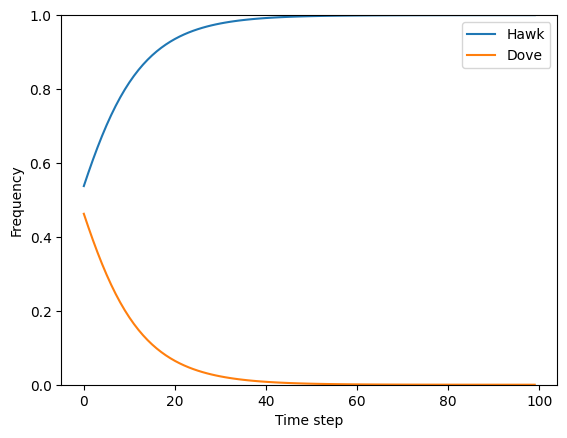

In [41]:
plot_pd_dynamics(hawk_dove_proportions)

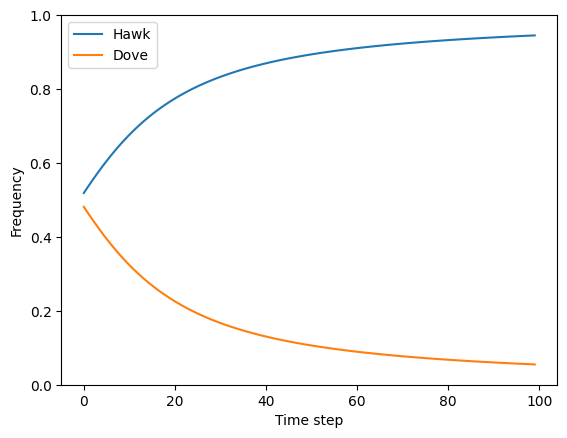

In [42]:
plot_pd_dynamics(hawk_dove_proportions, plot_average_strategy=True)

# 2) War of attrition

In [68]:
wat_v = 2
wat_c = 10

In [69]:
wat_p1_payoffs = np.array([[0, 0], [0, wat_v]])
wat_p2_payoffs = np.array([[wat_v, 0], [wat_v - (wat_c/2), wat_v - (wat_c/2)]])

In [70]:
wat = gbt.Game.from_arrays(
    wat_p1_payoffs,
    wat_p2_payoffs,
    title="War of attrition"
)
wat

,1,2
1,"0,2.0","0,0.0"
2,"0,-3.0","2,-3.0"


In [71]:
ops_wat = pyspiel.create_matrix_game(
    wat.title,
    wat.title,  # description
    [strategy.label for strategy in wat.players[0].strategies],
    [strategy.label for strategy in wat.players[1].strategies],
    wat_p1_payoffs,
    wat_p2_payoffs
)

In [72]:
state = ops_wat.new_initial_state()
state.apply_actions([1, 1])
state

Terminal? true
History: 1, 1
Returns: 2,-3
Row actions: 
Col actions: 
Utility matrix:
0,2 0,0 
0,-3 2,-3 

In [73]:
gbt.nash.lcp_solve(wat).equilibria[0]

[[Rational(1, 1), Rational(0, 1)], [Rational(1, 1), Rational(0, 1)]]

In [74]:
matrix_wat_payoffs = game_payoffs_array(ops_wat)
wat_dyn = dynamics.MultiPopulationDynamics(matrix_wat_payoffs, dynamics.replicator)

def plot_wat_dynamics(
    pop1_proportions,
    pop2_proportions,
    steps=100,
    alpha=0.1,
    plot_average_strategy=False,
):
    # Build full state vector
    x = np.concatenate([
        np.array(pop1_proportions),
        np.array(pop2_proportions),
    ])

    ks = matrix_hd_payoffs.shape[1:]  # (2, 2)
    assert x.shape[0] == sum(ks)

    traj = []

    for _ in range(steps):
        x = x + alpha * hd_dyn(x)

        # keep populations normalized (important for Euler steps)
        p1, p2 = np.split(x, np.cumsum(ks)[:-1])
        p1 = np.clip(p1, 1e-9, 1)
        p2 = np.clip(p2, 1e-9, 1)
        p1 /= p1.sum()
        p2 /= p2.sum()
        x = np.concatenate([p1, p2])

        traj.append(x.copy())

    traj = np.array(traj)

    # Extract hawk proportions
    hawk_p1 = traj[:, 0]
    hawk_p2 = traj[:, 2]

    plt.plot(hawk_p1, label="Hawk (population 1)")
    plt.plot(hawk_p2, label="Hawk (population 2)")
    plt.ylim(0, 1)
    plt.xlabel("Time step")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()


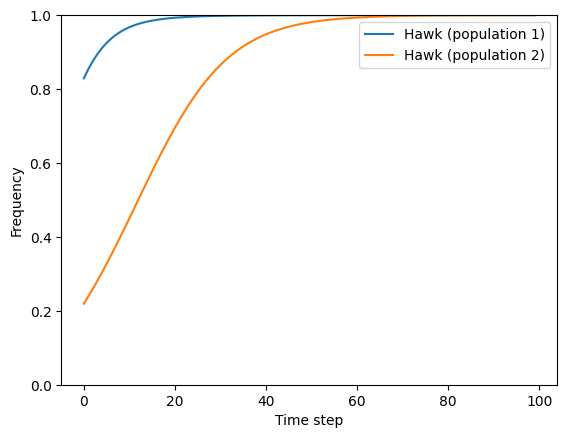

In [75]:
plot_wat_dynamics(
    pop1_proportions=[0.8, 0.2],  # Hawk, Dove
    pop2_proportions=[0.2, 0.8],
)